# Residuals, Interval Calibration And Inventory Policy

Point accuracy is not sufficient for inventory decisions. This notebook checks residual normality, autocorrelation, heteroscedasticity and scale dependence, then validates split-conformal 90% intervals and converts them into MOQ/order-multiple constrained policy evidence.


In [1]:
from pathlib import Path
import json
import pandas as pd
try:
    from IPython.display import Image, display
except ImportError:
    class Image:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return f"Image({self.filename})"
    def display(value): print(value)

ROOT = Path.cwd()
if ROOT.name != "v8_controlled_synthetic_validation":
    candidate = ROOT / "Ai miroservices/modeling/v8_controlled_synthetic_validation"
    ROOT = candidate if candidate.exists() else ROOT
OUT = ROOT / "outputs"
DATA = OUT / "data"
PLOTS = OUT / "plots"
EVAL = OUT / "evaluator"
summary = json.loads((OUT / "run_summary.json").read_text())


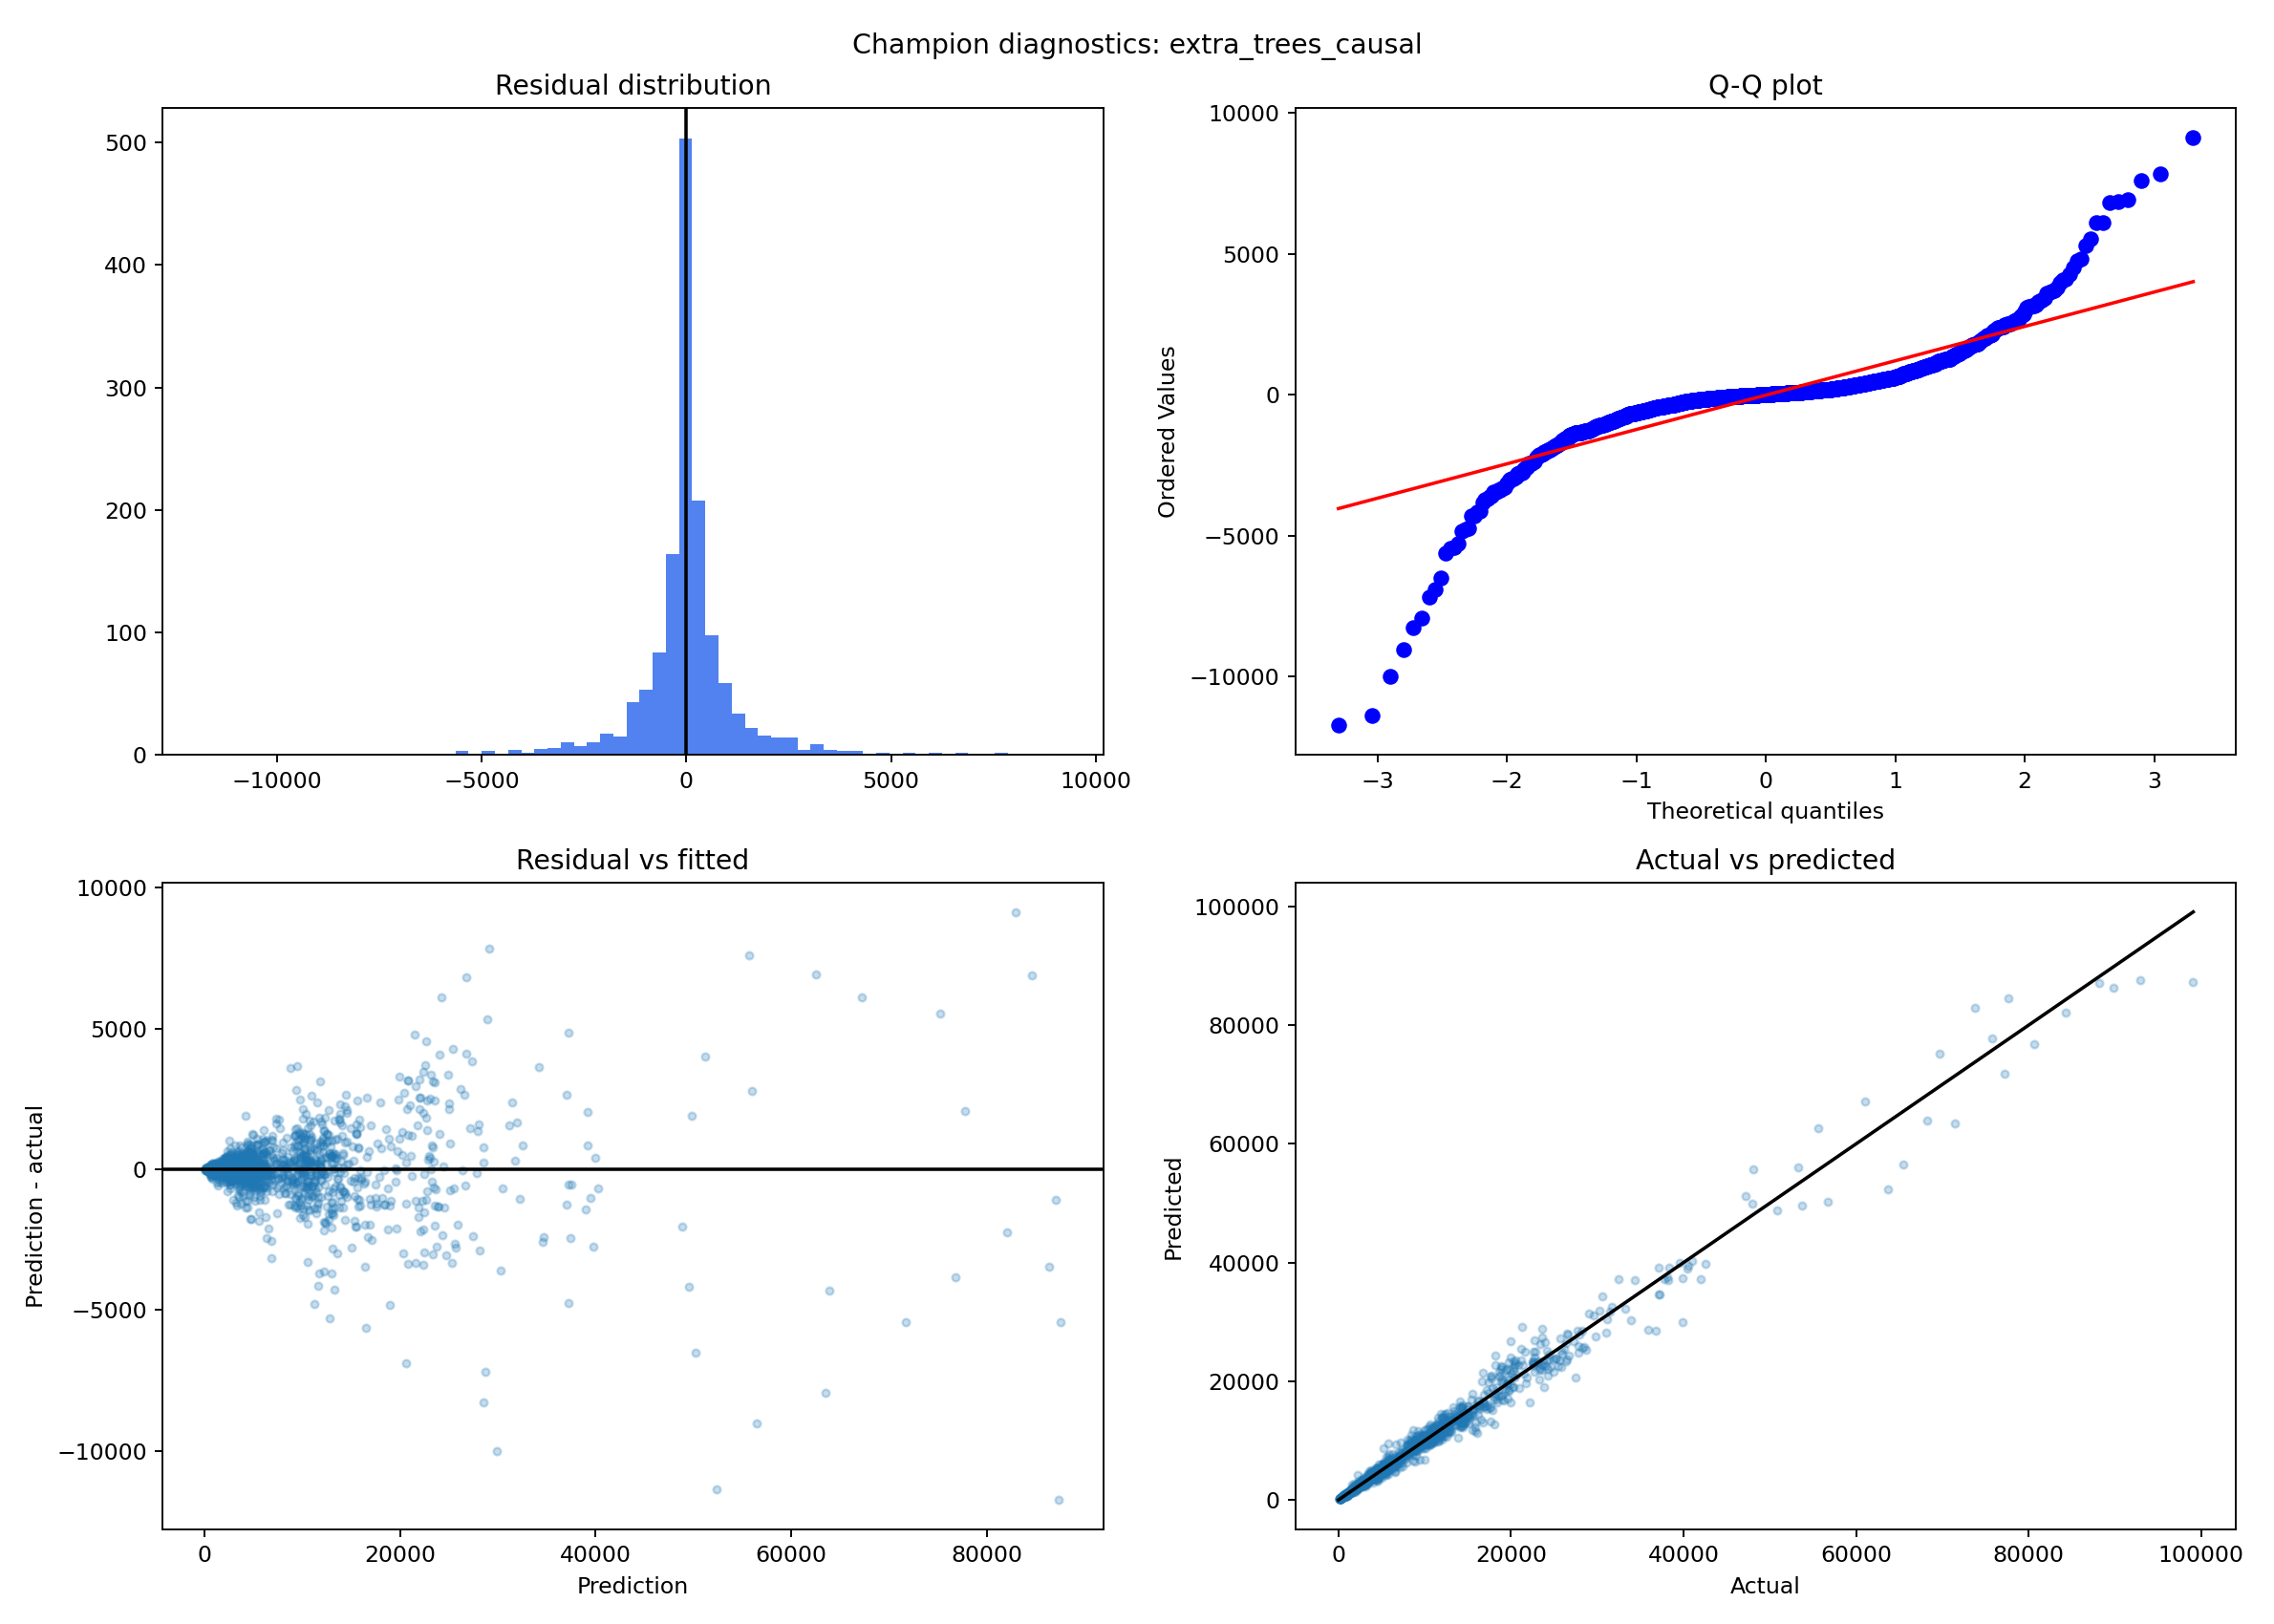

In [2]:
display(Image(filename=str(PLOTS / '03_champion_residual_diagnostics.png')))


In [3]:
residual_tests = pd.read_csv(OUT / "residual_tests.csv")
calibration = pd.read_csv(OUT / "interval_calibration.csv")
display(residual_tests)
display(calibration)


,test,statistic,p_value,null_hypothesis
0,Jarque-Bera normality,16208.048424,0.000000e+00,residuals are normally distributed
1,Ljung-Box monthly mean residual lag 4,4.571595,3.341423e-01,no residual autocorrelation
2,Breusch-Pagan,472.250888,1.037437e-104,constant residual variance
3,Spearman abs residual vs fitted,0.732158,4.442027e-242,no monotonic scale-error relationship


,model,nominal_coverage,empirical_coverage,normalized_error_quantile,average_interval_width,calibration_rows,test_rows
0,extra_trees_causal,0.9,0.920833,0.191629,3382.347528,720,1440


In [4]:
policy = pd.read_csv(OUT / "inventory_policy_simulation.csv")
policy[["material_code", "material_type", "monthly_p50", "monthly_p90", "reorder_point", "safety_stock", "moq", "order_multiple", "order_quantity", "proposed_min", "proposed_max"]].head(20).round(2)


,material_code,material_type,monthly_p50,monthly_p90,reorder_point,safety_stock,moq,order_multiple,order_quantity,proposed_min,proposed_max
0,RM-0001,raw_material,623.34,742.79,292.84,75.00,600,200,1000.0,367.85,1367.85
1,RM-0002,raw_material,4025.44,4796.83,6461.44,895.29,350,50,700.0,7356.73,8056.73
2,RM-0003,raw_material,13528.43,16120.87,10063.13,2048.24,150,50,14950.0,12111.37,27061.37
3,RM-0004,raw_material,1264.75,1507.11,643.69,158.39,50,10,1730.0,802.08,2532.08
4,RM-0005,raw_material,8211.69,9785.29,3536.37,945.99,175,25,11950.0,4482.35,16432.35
5,RM-0006,raw_material,14198.79,16919.69,16676.49,2701.27,1000,200,9200.0,19377.76,28577.76
6,RM-0007,raw_material,4451.21,5304.19,5750.75,888.16,50,10,2270.0,6638.91,8908.91
7,RM-0008,raw_material,22908.99,27299.02,12556.43,2977.33,200,100,30300.0,15533.76,45833.76
8,RM-0009,raw_material,55011.83,65553.69,45228.01,8756.33,30,10,56040.0,53984.34,110024.34
9,RM-0010,raw_material,10280.53,12250.57,4427.31,1184.32,20,10,14950.0,5611.63,20561.63


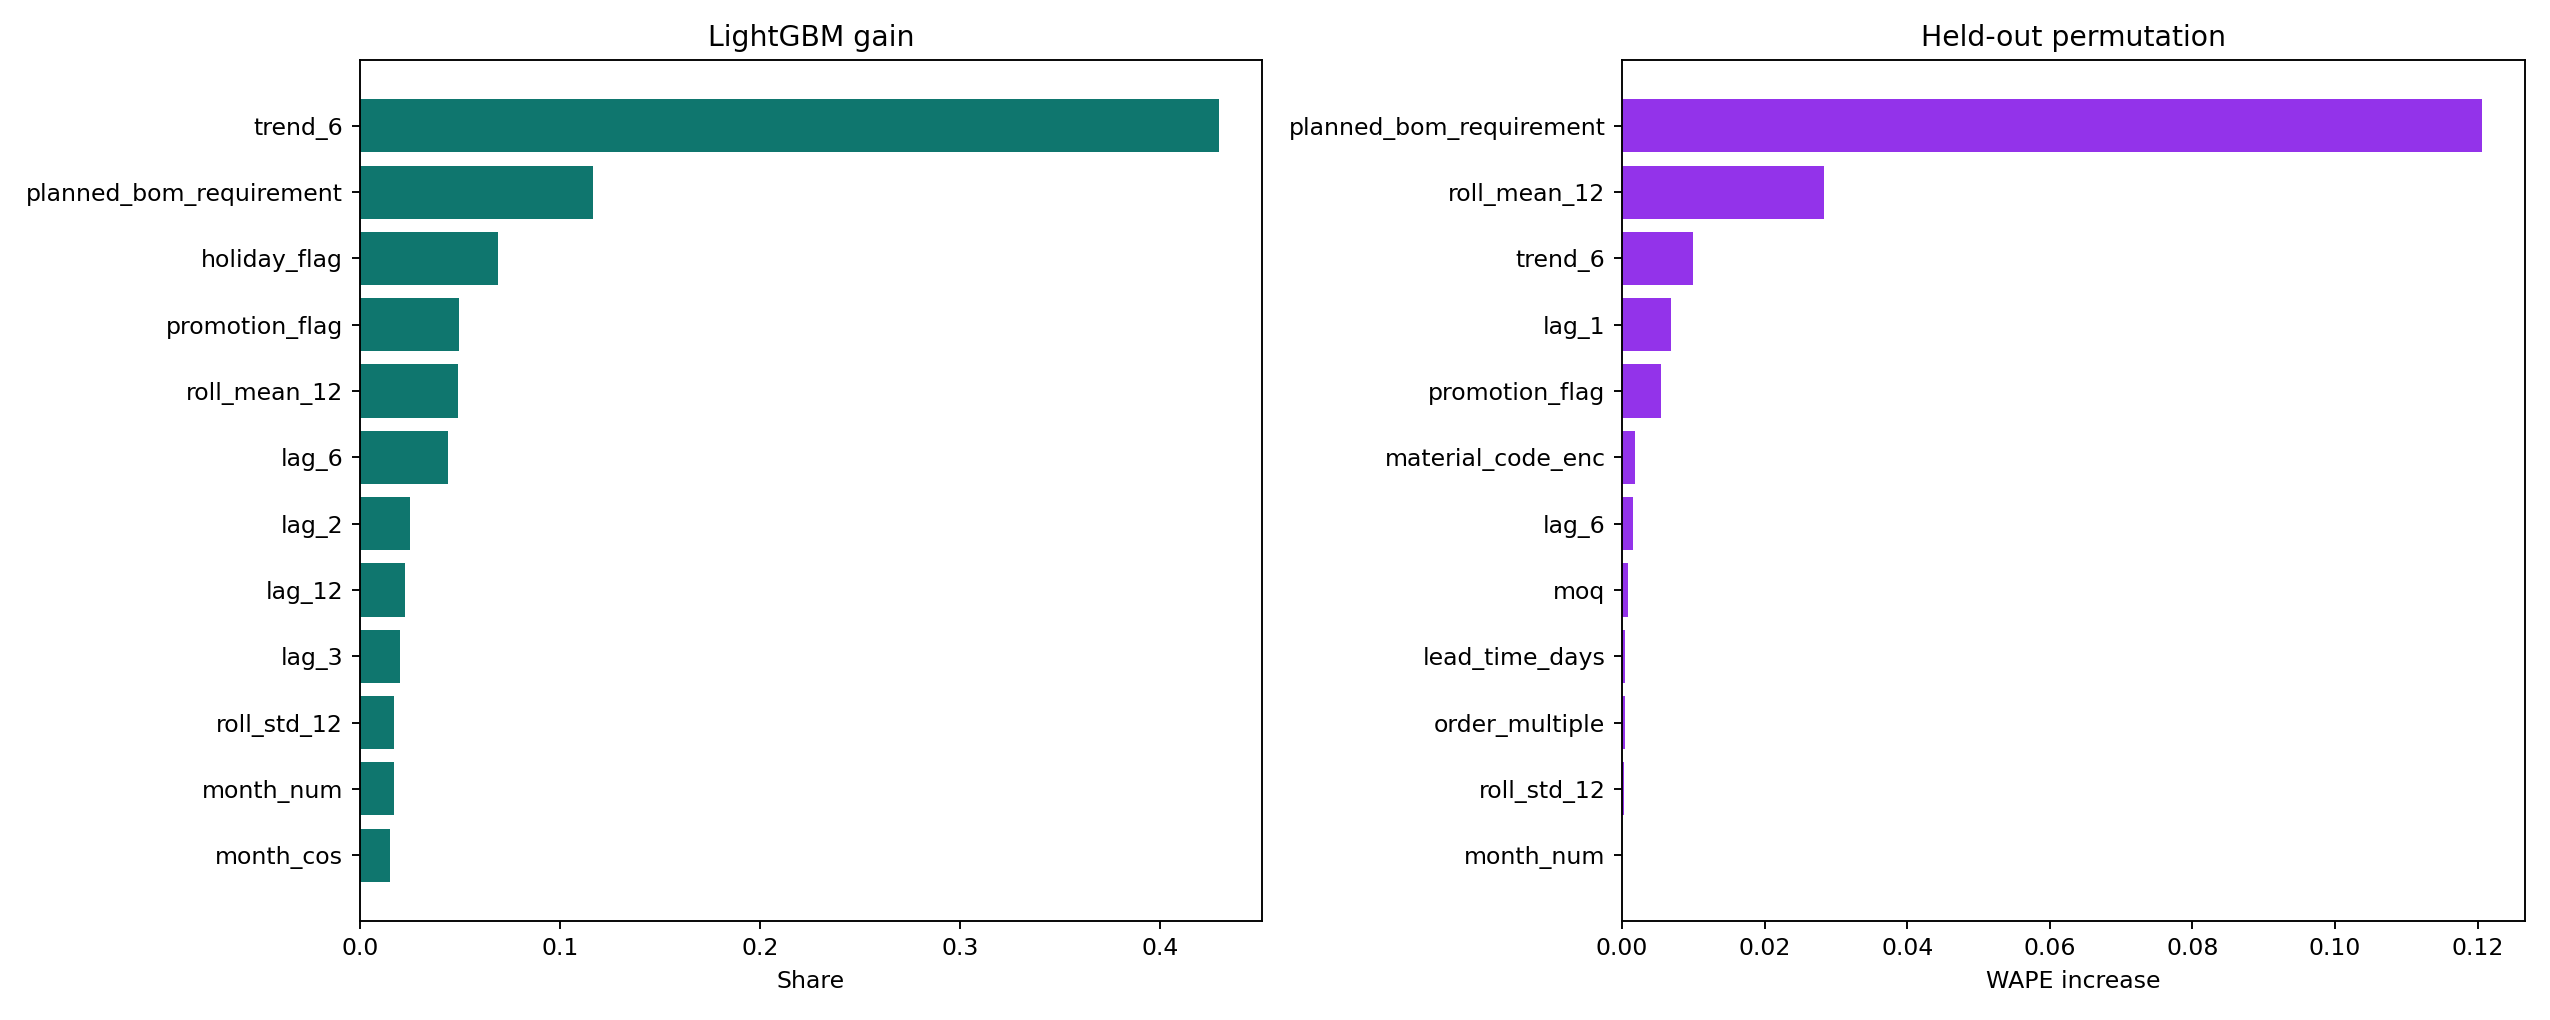

,feature,gain,split,gain_share
0,trend_6,189.957437,957,0.429406
1,planned_bom_requirement,51.605414,1712,0.116656
2,holiday_flag,30.647639,106,0.069280
3,promotion_flag,22.013349,146,0.049762
4,roll_mean_12,21.809605,707,0.049301
5,lag_6,19.542432,433,0.044176
6,lag_2,11.122150,440,0.025142
7,lag_12,9.944848,531,0.022481
8,lag_3,8.848981,374,0.020003
9,roll_std_12,7.502087,469,0.016959


,feature,baseline_WAPE,permuted_WAPE_increase_mean,permuted_WAPE_increase_std
0,planned_bom_requirement,0.087308,0.120540,0.009694
1,roll_mean_12,0.087308,0.028268,0.011550
2,trend_6,0.087308,0.009975,0.003873
3,lag_1,0.087308,0.006822,0.001474
4,promotion_flag,0.087308,0.005447,0.004338
5,material_code_enc,0.087308,0.001840,0.001230
6,lag_6,0.087308,0.001535,0.003739
7,moq,0.087308,0.000842,0.000563
8,lead_time_days,0.087308,0.000479,0.000835
9,order_multiple,0.087308,0.000401,0.000565


In [5]:
gain = pd.read_csv(OUT / "lightgbm_gain_importance.csv")
permutation = pd.read_csv(OUT / "lightgbm_permutation_importance.csv")
display(Image(filename=str(PLOTS / "05_feature_importance.png")))
display(gain.head(15))
display(permutation.head(15))


In [6]:
evaluator_rows=pd.read_csv(EVAL/'backtest_rows.csv.gz')
evaluator_rows['residual']=evaluator_rows.y_true-evaluator_rows.prediction
display(evaluator_rows.groupby(['split','model_name']).residual.agg(['mean','std','count']))


mean          std  count
split          model_name                                             
selection      CONV1D_ATTENTION_GLOBAL  664.035194  1946.655568   1440
               SEASONAL_NAIVE           626.293628  2208.795716   1440
untouched_test CONV1D_ATTENTION_GLOBAL  275.954728  1600.894804   1440
               SEASONAL_NAIVE           520.139882  2161.679214   1440